In [48]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import qutip as qt
from IPython.display import display, Math, Latex

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

# files = sorted(glob.glob("error_*.txt"))
#  N=2 偏离直线太多了
initial = "111"
N = 5
gammas = [0.1, 1.0]
gamma_linestyles = {0.1: "-", 1.0: "--"}

# coefficients for extrapolation
b_list = np.array([-1 / 1152, 64 / 675, -729 / 1600, 117649 / 86400])

N_list = np.array([2, 3, 4, 5, 6])

r1_list = np.array([1, 2, 3, 7])

si_z = [
    qt.tensor([qt.qeye(2)] * i + [qt.sigmaz()] + [qt.qeye(2)] * (N - i - 1))
    for i in range(N)
]

O = sum([si_z[i] for i in range(N)]).full()

# record extrapolated observable values and max-r observable values for each gamma and scale
plot_data = {}

for gamma in gammas:
    rho_superexact = np.load(
        f"../jobs/|{initial}>extrapolated/gamma_{gamma}/rho_superexact_N_{N}_no_Euler.npy"
    )
    O_superexact = np.real(np.trace(O @ rho_superexact))

    scales = []
    extrapolated_list = []
    max_r_list = []

    for scale in range(1, 11):
        O_list = []
        file_paths = [
            Path(f"../jobs/|{initial}>extrapolated/gamma_{gamma}/rho_N_{N}_r_{scale * r}_no_Euler.npy")
            for r in r1_list
        ]
        if not all(path.exists() for path in file_paths):
            continue

        for path in file_paths:
            rho_Trotter = np.load(path)
            O_list.append(np.real(np.trace(O @ rho_Trotter)))

        scales.append(scale)
        max_r_list.append(O_list[-1])
        extrapolated_O = sum(b * O for b, O in zip(b_list, O_list))
        extrapolated_list.append(extrapolated_O)

    plot_data[gamma] = {
        "scales": np.asarray(scales),
        "extrapolated": np.asarray(extrapolated_list),
        "max_r": np.asarray(max_r_list),
        "superexact": O_superexact,
    }

    print(f"gamma={gamma}: available scales = {scales}")
    print("Extrapolated values:", extrapolated_list)
    print("Max r values:", max_r_list)

gamma=0.1: available scales = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Extrapolated values: [np.float64(-1.7870905226784346), np.float64(-1.8245881151408794), np.float64(-1.8243224382644168), np.float64(-1.8243179456423302), np.float64(-1.8243176101044103), np.float64(-1.824317561663674), np.float64(-1.8243175512681247), np.float64(-1.8243175484096783), np.float64(-1.8243175474706008), np.float64(-1.8243175470599666)]
Max r values: [np.float64(-1.8937676209539922), np.float64(-1.8417036954097528), np.float64(-1.8320453222435915), np.float64(-1.8286644863959187), np.float64(-1.8270996020132662), np.float64(-1.826249533814869), np.float64(-1.8257369674521844), np.float64(-1.8254042914504938), np.float64(-1.8251762095746078), np.float64(-1.8250130638008577)]
gamma=1.0: available scales = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Extrapolated values: [np.float64(3.2305496743760886), np.float64(3.2376002859677513), np.float64(3.2375562254053496), np.float64(3.237552416559356), np.float64(3.237552632806649), n

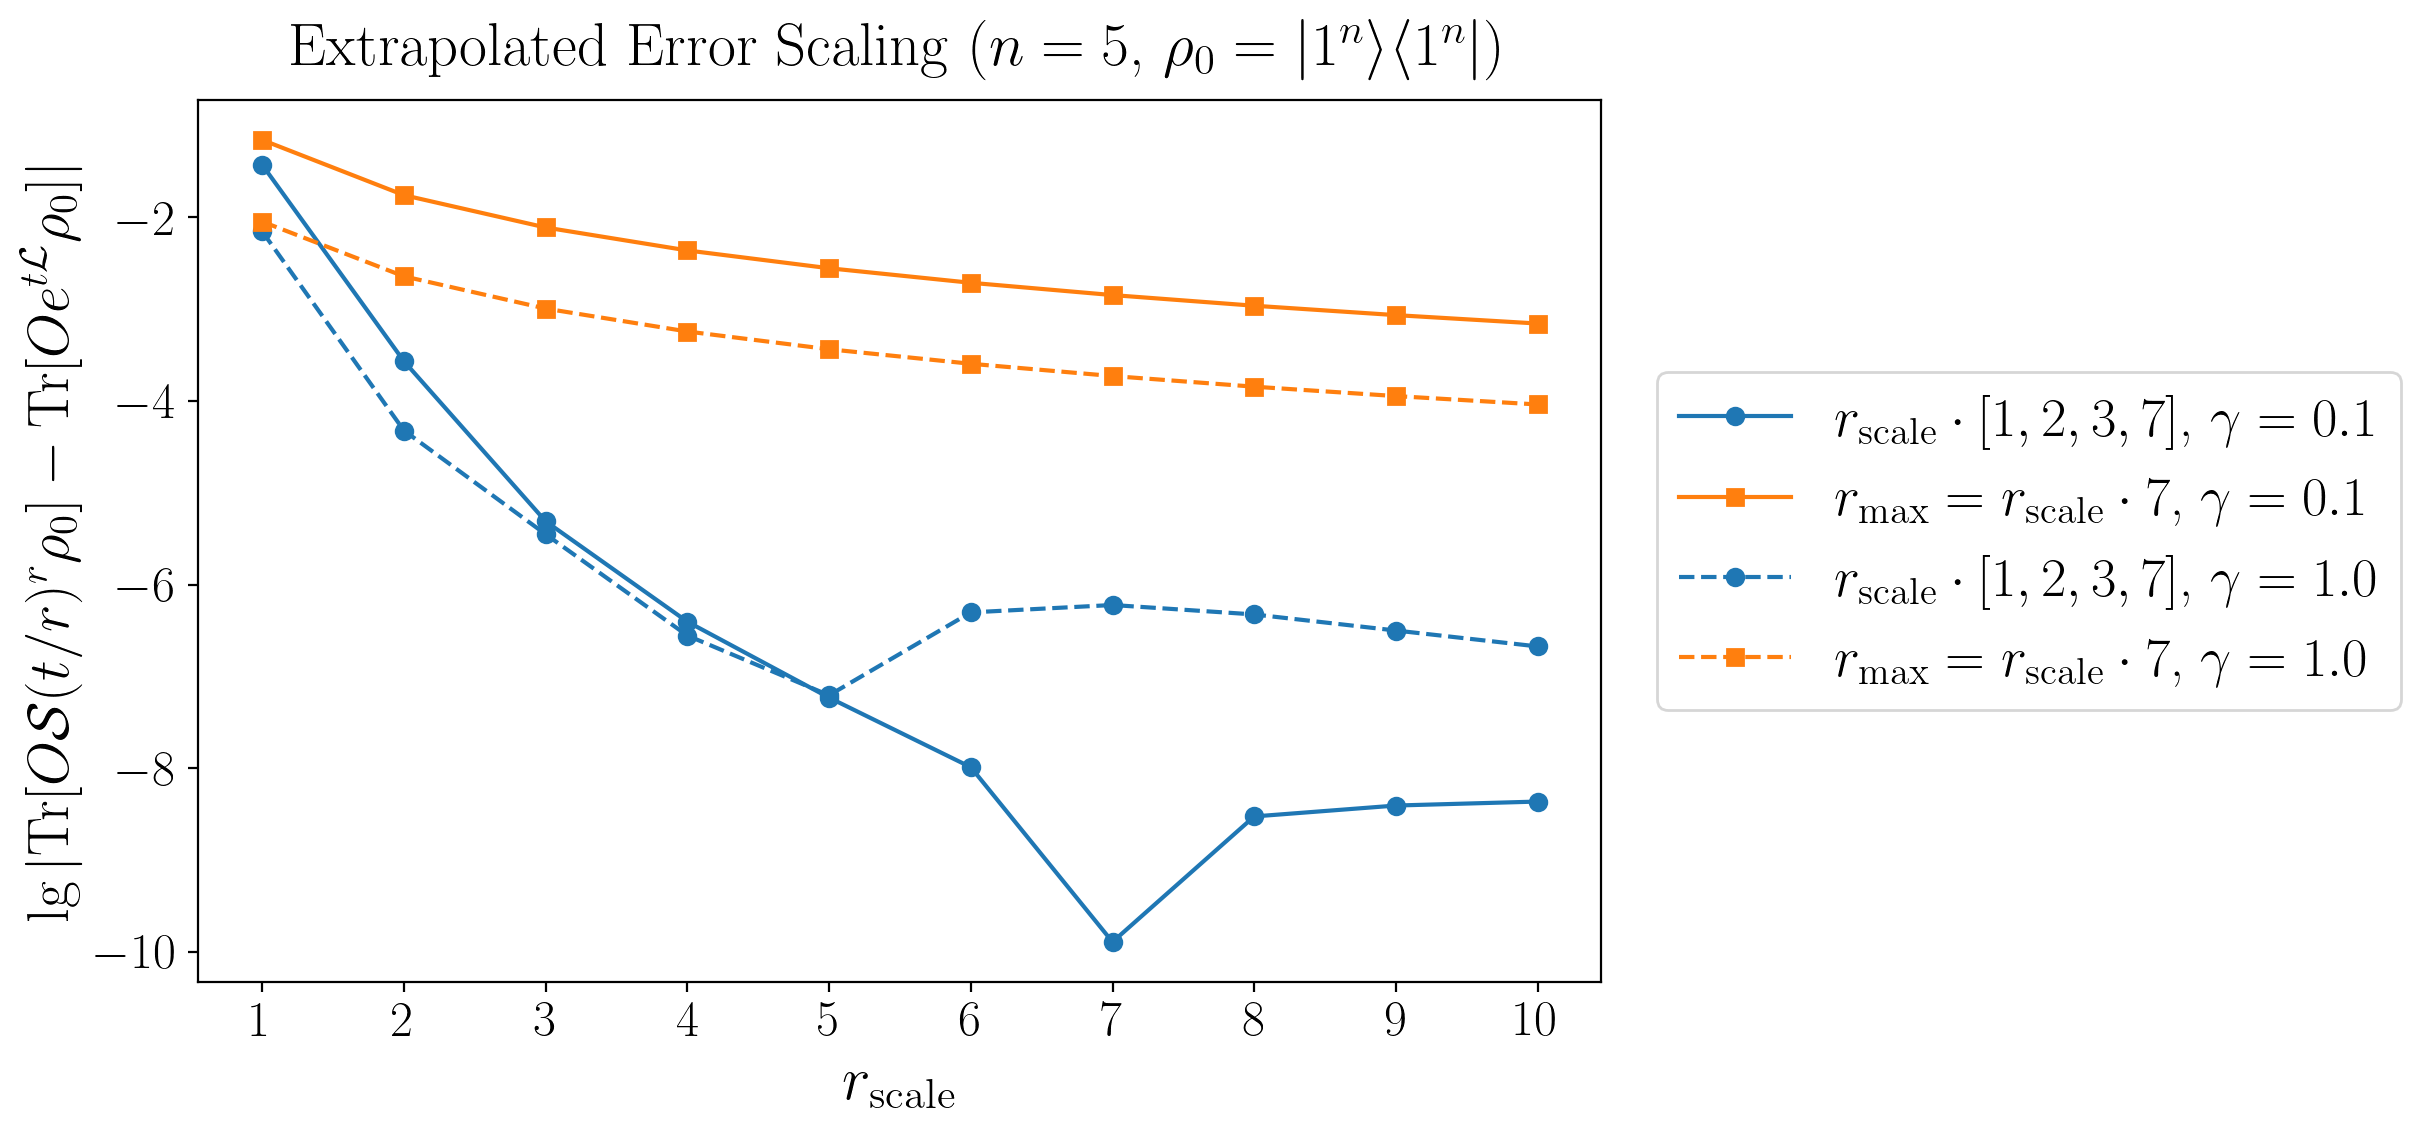

In [49]:
fig, ax = plt.subplots(figsize=(12.5, 6))

for gamma in gammas:
    scales = plot_data[gamma]["scales"]
    extrapolated_arr = plot_data[gamma]["extrapolated"]
    max_r_arr = plot_data[gamma]["max_r"]
    O_superexact = plot_data[gamma]["superexact"]
    linestyle = gamma_linestyles[gamma]

    ax.plot(
        scales,
        np.log10(np.abs(extrapolated_arr - O_superexact)),
        color="C0",
        marker="o",
        linestyle=linestyle,
        label=rf"$r_{{\mathrm{{scale}}}}\cdot[1,2,3,7]$, $\gamma={gamma}$",
        # label=rf"Extrapolated $r_{{\mathrm{{scale}}}}\cdot[1,2,3,7]$, $\gamma={gamma}$",
    )
    ax.plot(
        scales,
        np.log10(np.abs(max_r_arr - O_superexact)),
        color="C1",
        marker="s",
        linestyle=linestyle,
        label=fr"$r_{{\max}}=r_{{\mathrm{{scale}}}}\cdot 7$, $\gamma={gamma}$",
    )

# Richardson extrapolation
# Largest-r baseline

ax.set_xlabel("$r_{\mathrm{scale}}$", fontsize=22)
ax.set_ylabel(
    "$\lg|\mathrm{Tr}[O\mathcal{S}(t/r)^r\\rho_0]-\mathrm{Tr}[Oe^{t\mathcal{L}}\\rho_0]|$",
    fontsize=21,
)

ax.set_xticks(range(1, 11))
# ax.set_xticklabels(range(2, 12))
# ax.set_yticks(np.arange(-22, 0, 4))
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=20)
ax.set_title(f"Extrapolated Error Scaling ($n={N}$, $\\rho_0=|1^n\\rangle\langle1^n|$)", fontsize=22, y=1.02)
fig.tight_layout()
plt.savefig(f"extrapolation-{N}-{initial}_scaling.pdf")
plt.show()